In [4]:
# uncomment this line if you need to install pyphyschemtools
# (remove "# " - don't forget to remove the empty space)
# 1. Force uninstall the old version completely
# !pip uninstall pyNanoMatBuilder -y

# 2. Install the new version with flags that bypass all caches and force a refresh
# !pip install --index-url https://test.pypi.org/simple/ pyNanoMatBuilder==0.9.0 --no-cache-dir --no-deps

# Optional: only necessary if you want to visualize 3D structures directly within the notebook.
# !pip install pyphyschemtools

<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyNanoMatBuilder/blob/main/pyNMB-examples.ipynb)

</div>

pyNanoMatBuilder: parallelism set to 4 threads.



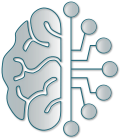

**Environment initialized:** Sunday 14 June 2026, 13:14:15 on localhost.localdomain  
<span style='color: #007a7a; font-weight: bold;'>[OK] Parallel computing ENABLED (4 threads)</span>

pyNMB.__version__='0.16.0'


In [1]:
# # development purpose only. Comment these 2 lines on Google Colab
%load_ext autoreload
%autoreload 2
#------------------------------

##################
# Initialization #
##################
import pyNanoMatBuilder as pyNMB
pyNMB.set_threads(4)
pyNMB.init()
%matplotlib inline
print(f"{pyNMB.__version__=}")

from pyNanoMatBuilder import utils as pyNMBu
import pyNanoMatBuilder as pyNMB

# Article

## Figure of the article that introduce pyNanoMatBuilder

<div class="appE">

Illustrative capabilities of pyNanoMatBuilder, with Two atomistic models obtained by combining several advanced operations: (a, left) A multiply-twinned particle whose facets have been hollowed into concave cavities by symmetry-constrained slicing, with a gold nanowire attached by constructive solid geometry; (a, right) two surface-carved cubes, each facet bearing an X-shaped motif and a local twist applied to a controlled depth below the surface, joined by a gold nanowire. Neither structure corresponds to a Platonic, Archimedean, Catalan, or Johnson solid. Observables simulated directly from the atomic coordinates are displayed below: (b) small- and wide-angle X-ray scattering profiles (SAXS/WAXS) and (c) a multislice HRTEM image. These examples are intended to showcase the morphological and simulation range of pyNMB rather than to model a specific experimental nanoparticle. The script generating these structures is provided as an advanced tutorial notebook distributed with pyNMB.
</div>

### Silver icosahedron decorated with gold Ino decahedra on its 12 vertice 

#### Generation of the bimetallic structure

<div class="intro">

This advanced tutorial combines two multiply-twinned objects into one composite nanostructure. We start from a regular icosahedron (the core) and graft a small Ino decahedron onto each of its 12 vertices, with the decahedron tip pointing outward, producing a 12-pointed star. The construction works because both objects share the same crystallographic origin: an icosahedron and a decahedron are both built from the five-fold twinning of fcc tetrahedra. As a result, the pentagonal crown around an icosahedron vertex and the pentagonal tip of a decahedron share the same apex half-angle (58.28°) and the same azimuth (54° mod 72°) in their own frames. They are made to mate, point-to-point, five against five.
The core is silver and the decahedra are gold, so that we can later remove the decahedra selectively by chemical element.

Before manipulating any geometry, it is always worth recalling which **attributes** (geometric descriptors) and **methods** (operations) an object
exposes. The construction cell below prints both, using `pyNMBu.listOf_Attributes_Methods`:
 
```python
pyNMBu.listOf_Attributes_Methods(ico, show_methods=False)   # icosahedron: attributes only
pyNMBu.listOf_Attributes_Methods(ino, show_methods=True)    # Ino decahedron: attributes + methods
```
 <br>
The attributes differ between the two objects (their geometry is not the same: number of faces, vertices, circumscribed radius, etc.), so we list them
for each. The **methods**, on the other hand, are identical for every pyNMB object, they are all inherited from the same `pyNMBcore` class. So we print
them only once, on the Ino decahedron (`show_methods=True`), and omit them for the icosahedron (`show_methods=False`) to avoid redundancy.
 
This is exactly where we find the building blocks used later: the attributes `vertices`, `radiusCircumscribedSphere`, `equations`, and the methods `union_with`, `optimize`, `delete`, `write`, among others.
</div>

##### Ico and ino

In [16]:
import numpy as np

from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import johnsonNPs as jNP
from pyNanoMatBuilder import utils as pyNMBu

# ---------------------------------------------------------------------------
#  Tunable parameters
# ---------------------------------------------------------------------------
nShells   = 8
element   = "Ag"
Rnn       = 2.9         # Ag fcc nearest-neighbour distance, Å

# ---------------------------------------------------------------------------
#  1.  Core icosahedron
# ---------------------------------------------------------------------------
pyNMBu.centertxt("core icosahedron", size=18, weight="bold", bgc="#880002")
ico = pNP.regIco(element, Rnn, nShells,
                  skipSymmetryAnalyzis=True, noOutput=True)

pyNMBu.write("coords/decorated_ico/ico_pristine.xyz", ico.NP)

# ---------------------------------------------------------------------------
#  2.  Cutter = Ino decahedron
# ---------------------------------------------------------------------------

sizeP   = 3         # pentagon size (its circumradius scales with this)
sizeE   = 3         # elongation  -> Ino character (>0). Set 0 for regular.
Marks   = 0         # 0 -> Ino (no re-entrant truncation)


# ---------------------------------------------------------------------------
#  6. Build the Ino decahedron
# ---------------------------------------------------------------------------
pyNMBu.centertxt("Ino decahedron", size=18, weight="bold", bgc="#880002")
ino = jNP.epbpyM(
    "Au",
    Rnn,
    sizeP=sizeP,
    sizeE=sizeE,
    Marks=Marks,
    skipSymmetryAnalyzis=True,
    thresholdCoreSurface=1,
    noOutput=True,
)
pyNMBu.write("coords/decorated_ico/ino_cutter.xyz", ino.NP)

In [17]:
pyNMBu.centertxt("Attributes of the icosahedron",size=20, bgc="#550000",weight="bold")
pyNMBu.listOf_Attributes_Methods(ico, show_methods=False)
pyNMBu.centertxt("Attributes of the ino decahedron",size=20, bgc="#550000",weight="bold")
pyNMBu.listOf_Attributes_Methods(ino, show_methods=True)

  NP                             : Atoms    Ag2057  (N=2057)
  NPR                            : ndarray  shape=(2,)  dtype=float64
  NPcs                           : Atoms    Ag642No1415  (N=2057)
  Rg                             : np.float64(1.5437866651214152)
  Rnn                            : 2.9
  area_Hull                      : 46.61295133329366
  aseView                        : False
  calcPropOnly                   : False
  chirality                      : 'achiral'
  cnp                            : ndarray  shape=(2057,)  dtype=float64
  cnp_core_threshold             : 22.6
  cnp_mean                       : 8.48830212575628
  cog                            : ndarray  shape=(3,)  dtype=float64
  double_ico                     : False
  edgeLengthF                    : 1
  element                        : 'Ag'
  ellipsoid                      : dict     keys=['initial structure']
  equations                      : ndarray  shape=(20, 4)  dtype=float64
  imageFile          

  G                              : None
  Gstar                          : None
  NPR_opt                        : None
  NP_opt                         : None
  NP_preview                     : None
  NP_select                      : None
  NP_select_mask                 : None
  NP_select_mask_opt             : None
  NP_select_opt                  : None
  NPcs_opt                       : None
  Rg_opt                         : None
  WulffShape                     : None
  _local_order_decimals          : None
  area_Hull_opt                  : None
  cnp_mean_opt                   : None
  cnp_opt                        : None
  cog_opt                        : []
  equations_opt                  : None
  jMolCS_opt                     : None
  jMolCarvePreview               : None
  jMolSlices                     : None
  jMolStellationPreview          : None
  jMol_cnp_opt                   : None
  jMol_q4                        : None
  jMol_q4_opt                    : None
  

  Hollow                         : False
  Marks                          : 0
  Multiples_index_plan           : False
  NP                             : Atoms    Au147  (N=147)
  NPR                            : ndarray  shape=(2,)  dtype=float64
  NPcs                           : Atoms    Au92No55  (N=147)
  Rg                             : np.float64(0.6651602537060667)
  Rnn                            : 2.9
  area_Hull                      : 7.256731928251932
  aseView                        : False
  calcPropOnly                   : False
  chirality                      : 'achiral'
  cnp                            : ndarray  shape=(147,)  dtype=float64
  cnp_core_threshold             : 24.75
  cnp_mean                       : 23.276233416215792
  cog                            : ndarray  shape=(3,)  dtype=float64
  edgeLengthF                    : 1
  element                        : 'Au'
  ellipsoid                      : dict     keys=['initial structure']
  equations         

  G                              : None
  Gstar                          : None
  NPR_opt                        : None
  NP_opt                         : None
  NP_preview                     : None
  NP_select                      : None
  NP_select_mask                 : None
  NP_select_mask_opt             : None
  NP_select_opt                  : None
  NPcs_opt                       : None
  Rg_opt                         : None
  WulffShape                     : None
  _local_order_decimals          : None
  area_Hull_opt                  : None
  cnp_mean_opt                   : None
  cnp_opt                        : None
  cog_opt                        : []
  equations_opt                  : None
  jMolCS_opt                     : None
  jMolCarvePreview               : None
  jMolSlices                     : None
  jMolStellationPreview          : None
  jMol_cnp_opt                   : None
  jMol_q4                        : None
  jMol_q4_opt                    : None
  

  Inscribed_circumscribed_spheres
  MakeVertices
  _flush_stale_data
  _update_sasview_dims_from_spheres
  align_to_plane
  angles_between_planes
  applySlicing
  applyTwist
  apply_reflection
  apply_rotation
  apply_translation
  area
  center
  clip_to_cone
  clip_to_cylinder
  clip_to_ellipsoid
  clip_to_sphere
  common_neighbour_parameter
  coords
  copy
  crystallographic_angle
  cut_by
  defHelixShapeForJMol
  defLocalOrderColorForJMol
  defSlabShapeForJMol
  delete
  edgeLength
  edgeLength_after_truncation
  effective_diameter
  external_facets_info
  flush_inlay_with
  from_file
  from_slab
  generateSlab
  get_ellipsoid_analysis
  heightOfPyramid
  interPlanarSpacing
  interface_distance_histogram
  intersect_with
  local_order_populations
  nAtomsPerEdgeOfPC_after_truncation
  optimize
  peel_by_coordination
  peel_by_shifted_ellipsoid
  plot_local_order
  plot_npr_triangle
  plot_q4q6_map
  prop
  propPostMake
  remove_duplicates
  remove_plane
  replicate_by_reflection
  

##### CSG

<div class="intro">

Placing a decahedron on a vertex takes two rotations:

- **Axis alignment**: the decahedron five-fold axis is brought onto the vertex direction (tip pointing outward). The minimal rotation that does
this, however, drags the pentagonal tip to an azimuth that depends on which vertex is targeted: the same decahedron lands rotated differently
on different vertices.
- **Azimuth correction**: we therefore measure where a reference edge of the decahedron tip ends up after step 1, compare it to a reference edge
of the icosahedron crown at that vertex, and apply a residual spin about the vertex axis to bring the two pentagons into register. The spin is
computed independently for each vertex (it differs from vertex to vertex), which is what makes all 12 decahedra mate cleanly.

The five-fold axis is read robustly from the real geometry as the axis of revolution (the principal inertia axis whose two partners are degenerate),
so the method works for any decahedron elongation, short or long walls. We use `union_with(..., recenter=False)` so the reference frame does not
shift between the 12 calls; the structure is recentred once at the end.
</div>

In [18]:
# ---------------------------------------------------------------------------
#  Tunable
# ---------------------------------------------------------------------------
pitDepth = 10.0     # depth of each pentagonal pit, in Å. Tune visually.

# ---------------------------------------------------------------------------
#  Rotation helpers
# ---------------------------------------------------------------------------
def rot_matrix(axis, angle_deg):
    axis = np.asarray(axis, float); axis = axis / np.linalg.norm(axis)
    a = np.radians(angle_deg)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(a) * K + (1 - np.cos(a)) * (K @ K)

def rot_axis_angle(a, b):
    a = a / np.linalg.norm(a); b = b / np.linalg.norm(b)
    v = np.cross(a, b); s = np.linalg.norm(v); c = np.dot(a, b)
    if s < 1e-9:
        if c > 0:
            return np.array([0.0, 0, 1.0]), 0.0
        perp = np.array([1.0, 0, 0]) if abs(a[0]) < 0.9 else np.array([0, 1.0, 0])
        ax = np.cross(a, perp); ax /= np.linalg.norm(ax)
        return ax, 180.0
    return v / s, float(np.degrees(np.arctan2(s, c)))

def azimuth_of(vec, axis, ref1, ref2):
    return np.degrees(np.arctan2(vec @ ref2, vec @ ref1))


# ---------------------------------------------------------------------------
#  1.  Geometry of the two objects (own frames).
# ---------------------------------------------------------------------------
Rc_ico = ico.radiusCircumscribedSphere

# Ino: axis (apex direction) + a reference apex edge in the Ino frame.
Pino = ino.NP.get_positions(); Pino = Pino - Pino.mean(0)

# Robust 5-fold axis: the revolution axis = inertia axis whose two partners
# are degenerate (works for any elongation, short or long walls).
I = np.zeros((3, 3))
for r in Pino:
    I += np.dot(r, r) * np.eye(3) - np.outer(r, r)
moments, axes = np.linalg.eigh(I)
gaps = [abs(moments[(i+1) % 3] - moments[(i+2) % 3]) for i in range(3)]
inoAxis = axes[:, int(np.argmin(gaps))]
inoAxis /= np.linalg.norm(inoAxis)

# apex = farthest atom ALONG the 5-fold axis (not farthest in 3D)
proj = Pino @ inoAxis
# pick the sign so the apex is at +axis; if the most extreme is negative, flip
if abs(proj.min()) > abs(proj.max()):
    inoAxis = -inoAxis
    proj = -proj
inoApex = proj.max()                      # centre -> apex distance along axis
inoApexVec = inoAxis * inoApex            # apex position on the axis

# reference apex edge: an atom forming a 58.28 deg edge from the apex
e = Pino - inoApexVec
nrm = np.linalg.norm(e, axis=1)
mask = nrm > 1e-6
edirs = e[mask] / nrm[mask][:, None]
half = np.degrees(np.arccos(np.clip(edirs @ (-inoAxis), -1, 1)))
inoRefEdge = edirs[mask.nonzero()[0][np.argmin(np.abs(half - 58.283))]]  # one edge


# ---------------------------------------------------------------------------
#  2.  Icosahedron vertices + a reference crown edge per vertex.
# ---------------------------------------------------------------------------
Cico = ico.NP.get_positions(); cog = Cico.mean(0)
Vpos = Cico[np.asarray(ico.vertices, int)] - cog
Vdir = Vpos / np.linalg.norm(Vpos, axis=1, keepdims=True)


# ---------------------------------------------------------------------------
#  3.  Punch each vertex with per-vertex azimuth correction.
# ---------------------------------------------------------------------------
pyNMBu.centertxt("ico union with ino on all ico vertices", size=18, weight="bold", bgc="#880002")
D_nm = ((Rc_ico - pitDepth) + inoApex) / 10.0

for k in range(len(Vdir)):
    d = Vdir[k]

    # (a) axis-alignment rotation: Ino axis -> -d (apex inward)
    ax, ang = rot_axis_angle(inoAxis, -d)
    R = rot_matrix(ax, ang)

    # where the Ino reference edge lands after alignment:
    edgeAfter = R @ inoRefEdge

    # build an azimuth frame around the vertex axis (-d at the tip):
    axisTip = -d
    u = np.array([1.0, 0, 0]) if abs(axisTip[0]) < 0.9 else np.array([0, 1.0, 0])
    e1 = np.cross(axisTip, u); e1 /= np.linalg.norm(e1)
    e2 = np.cross(axisTip, e1)

    # icosahedron crown reference edge at this vertex (toward a neighbour):
    nb = np.argsort(np.linalg.norm(Vpos - Vpos[k], axis=1))[1]
    crownEdge = Vpos[nb] - Vpos[k]; crownEdge /= np.linalg.norm(crownEdge)

    az_ino   = azimuth_of(edgeAfter, axisTip, e1, e2)
    az_crown = azimuth_of(crownEdge, axisTip, e1, e2)
    spin = (az_crown - az_ino + 36.0) % 72.0 - 36.0      # nearest match mod 72

    rotB = [{'axis': ax.tolist(), 'angle': ang},
            {'axis': (-d).tolist(), 'angle': float(spin)}]
    cogB = (D_nm * d).tolist()

    ico.union_with(ino.copy(), cogB=cogB, rotB=rotB, recenter=False,
                mode='hull', threshold=0.8, noOutput=True)
    print(f"vertex {k+1:02d}/12  spin = {spin:+6.2f} deg")


# ---------------------------------------------------------------------------
#  4.  Save
# ---------------------------------------------------------------------------
pyNMBu.write("coords/decorated_ico/ico_with_ino.xyz",    ico.NP)
pyNMBu.write("coords/decorated_ico/ico_with_ino.script", ico.jMolCS)
print(f"\nDone. D = {D_nm:.3f} nm, atoms left = {ico.nAtoms}")

vertex 01/12  spin = -31.72 deg
vertex 02/12  spin =  -4.28 deg
vertex 03/12  spin = +31.72 deg
vertex 04/12  spin =  +4.28 deg
vertex 05/12  spin = -18.00 deg
vertex 06/12  spin = +18.00 deg
vertex 07/12  spin = +18.00 deg
vertex 08/12  spin = -18.00 deg
vertex 09/12  spin = -36.00 deg
vertex 10/12  spin =  +0.00 deg
vertex 11/12  spin =  +0.00 deg
vertex 12/12  spin = -36.00 deg

Done. D = 2.121 nm, atoms left = 2801


##### Check that there is no large steric hinderance at the gold-silver interface

 - Closest Au-Ag distance : 2.56 Å
 - Ideal contact (Rnn)        : 2.90 Å
 - Interface atoms (<1.2·Rnn) : 390
 - Overlapping atoms (<0.85·Rnn = 2.46 Å) : 0


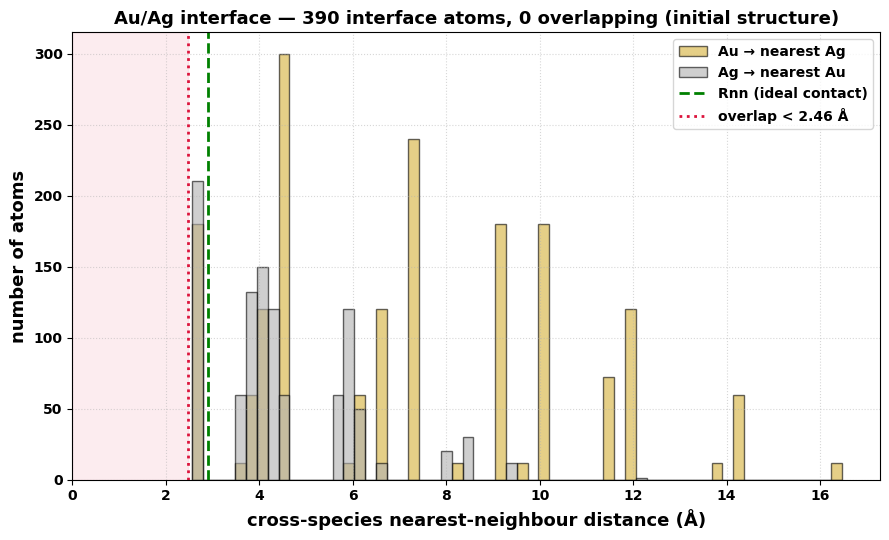

In [19]:
ico.interface_distance_histogram('Au', 'Ag', Rnn=2.9, noOutput=False);

##### Geometry optimization

<div class="intro">

The decorated star is first relaxed with `optimize()` to smooth the junctions between the grafted decahedra and the core. We then demonstrate the
`delete()` method: removing every gold atom (`elements="Au"`) strips off the 12 decahedra and leaves the bare silver core, which we relax again. Comparing
the decorated star and the stripped core shows how the grafting reshaped the vertices and the core.
</div>

 - Calculator                 : ase EMT calculator
 - Optimizer                  : ase Quasi Newton
 - Number of atoms            : 2801
 - XYZ frames will be saved to: ./coords/decorated_ico/ico_with_ino_opt_tmp.xyz
 - Initial potential energy   : 774.5 eV
 - Energy per atom            : 0.28 eV/atom
 - Max residual force         : 2.11 eV/Å  (threshold 0.15)



                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 13:29:22      774.506291       2.1109
BFGSLineSearch:    1[  1] 13:29:22      637.718238       0.7792
BFGSLineSearch:    2[  2] 13:29:40      614.083776       0.9753
BFGSLineSearch:    3[  3] 13:29:57      595.791713       0.4360
BFGSLineSearch:    4[  4] 13:30:17      586.935432       0.3197
BFGSLineSearch:    5[  5] 13:30:35      583.630081       0.2911
BFGSLineSearch:    6[  6] 13:30:53      580.173112       0.2489
BFGSLineSearch:    7[  8] 13:31:11      575.853097       0.4412
BFGSLineSearch:    8[ 10] 13:31:29      568.892268       1.0191
BFGSLineSearch:    9[ 12] 13:31:49      563.677778       0.3697
BFGSLineSearch:   10[ 13] 13:32:06      560.533705       0.2085
BFGSLineSearch:   11[ 14] 13:32:24      557.863425       0.1764
BFGSLineSearch:   12[ 15] 13:32:41      556.544688       0.2070
BFGSLineSearch:   13[ 16] 13:32:59      555.495445       0.1901
BFGSLineSearch:   14[ 17] 13:33:16     

 - Final potential energy     : 404.5 eV
 - Energy per atom            : 0.14 eV/atom
 - Max residual force         : 0.11 eV/Å  (threshold 0.15)


Moments of inertia = 111301227.67 111301227.67 111301227.67 amu.Å2
Moments of inertia / M = 242.32 242.32 242.32 amu.Å2
Moments of inertia with mass=1/M = 222.72 222.72 222.72 Å2


 Principal Moments : I1=242.32, I2=242.32, I3=242.32
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


...

372 atoms lie in the plane(s)
Duration : 00:00:00 010ms


 - Source            : optimized structure
 - Rnn               : 2.771 Å (auto-estimated)
 - Cutoff (cnp)      : 3.602 Å
 - Threshold (auto (largest gap)) : 21.550 Å²
 - Core atoms        : 1949 (69.6 %)
 - Surface atoms     : 852 (30.4 %)
 - Stored as         : self.surfaceAtoms_cnp_opt (True = surface)
Duration : 00:00:00 023ms


Diameter of the circumscribed sphere: 55.79 Å
Diameter of the inscribed sphere: 44.88 Å


  - Dimensions (Å): 55.79 x 55.79 x 55.79
  - Volume: 90.90 nm³
  - Surface: 97.77 nm²
  - Asphericity: 1.00
  - Max Radius found: 2.789 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {-1.485531 -23.744883 14.560152} {20.488033 -10.809390 -15.537756} {18.869499 9.867214 18.016781}; ellipsoid ID optimized_structure_el CENTER {0.000 0.000 -0.000}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:08:58 887ms


 - Closest Au-Ag distance : 2.49 Å
 - Ideal contact (Rnn)        : 2.90 Å
 - Interface atoms (<1.2·Rnn) : 1164
 - Overlapping atoms (<0.85·Rnn = 2.46 Å) : 0


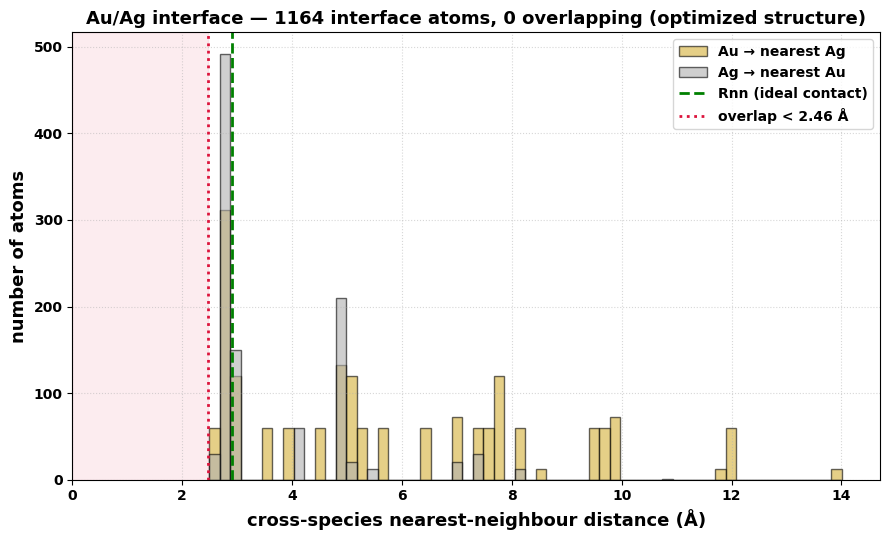

  1764 atoms designated, 2801 -> 1037 atoms (removed 1764).


Moments of inertia = 13702440.59 13702440.59 13702440.59 amu.Å2
Moments of inertia / M = 122.50 122.50 122.50 amu.Å2
Moments of inertia with mass=1/M = 122.50 122.50 122.50 Å2


 Principal Moments : I1=122.50, I2=122.50, I3=122.50
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 1.36 nm


Found:
  - 30 vertices
  - 56 simplices
  - Volume: 21.60 nm³
  - Area: 39.43 nm²
Duration : 00:00:00 002ms


...

Found:
  - 240 vertices
  - 476 simplices
  - Volume: 22.61 nm³
  - Area: 40.13 nm²
Duration : 00:00:00 003ms


270 atoms lie in the plane(s)
Duration : 00:00:00 006ms


 - Source            : optimized structure
 - Rnn               : 2.783 Å (auto-estimated)
 - Cutoff (cnp)      : 3.617 Å
 - Threshold (auto (largest gap)) : 21.950 Å²
 - Core atoms        : 767 (74.0 %)
 - Surface atoms     : 270 (26.0 %)
 - Stored as         : self.surfaceAtoms_cnp_opt (True = surface)
Duration : 00:00:00 008ms


Diameter of the circumscribed sphere: 36.69 Å
Diameter of the inscribed sphere: 32.46 Å


  - Dimensions (Å): 36.69 x 36.69 x 36.69
  - Volume: 25.85 nm³
  - Surface: 42.28 nm²
  - Asphericity: 1.00
  - Max Radius found: 1.834 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {0.000000 -17.740017 -4.663116} {0.000000 -4.663116 17.740017} {18.342652 0.000000 0.000000}; ellipsoid ID optimized_structure_el CENTER {0.000 -0.000 0.000}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:09 553ms


In [20]:
pyNMBu.centertxt("geometry optimization", size=18, weight="bold", bgc="#880002")
ico.optimize(noOutput=False, xyz_file="./coords/decorated_ico/ico_with_ino_opt_tmp.xyz", fthreshold=0.15)
pyNMBu.write("coords/decorated_ico/ico_with_ino_opt.xyz", ico.NP_opt)
ico.interface_distance_histogram('Au', 'Ag', Rnn=2.9, noOutput=False);
icowoI = ico.copy()
icowoI.delete(elements="Au", noOutput=False)
icowoI.optimize(noOutput=False, xyz_file="./coords/decorated_ico/ico_wo_ino_opt_tmp.xyz", fthreshold=0.15)
pyNMBu.write("coords/decorated_ico/ico_wo_ino_opt.xyz", icowoI.NP_opt)

#### Post-processing: local order descriptors, CNP and (q4, q6) 

 - Source              : initial structure
 - Cutoff Xnn          : 3.835 Å
 - Mean CNP <Q>        : 17.206 Å²
 - CNP range           : 0.024 – 81.629 Å²
 - Stored as           : self.cnp  (per atom), self.cnp_mean  (scalar)
Duration : 00:00:00 020ms


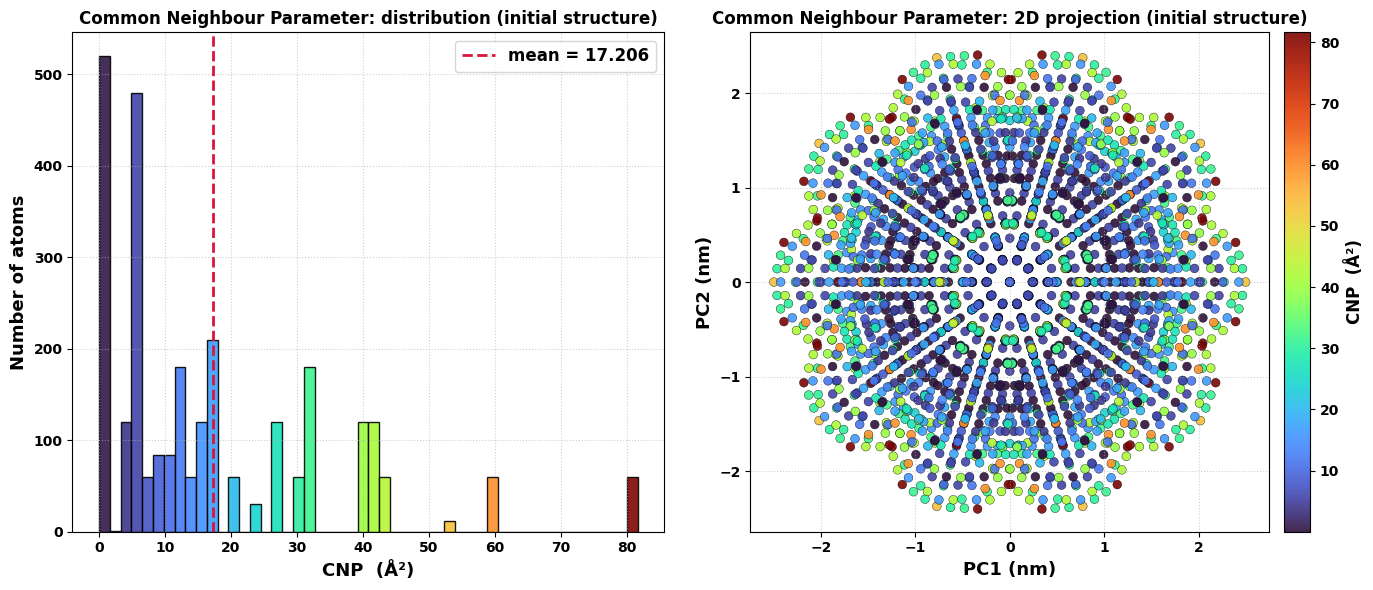

 - [ 0]        CNP (Å²)     0.02  →     120 atoms (  4.3 %)
 - [ 1]        CNP (Å²)     0.03  →      60 atoms (  2.1 %)
 - [ 2]        CNP (Å²)     0.04  →      20 atoms (  0.7 %)
 - [ 3]        CNP (Å²)     0.06  →      20 atoms (  0.7 %)
 - [ 4]        CNP (Å²)     0.07  →     120 atoms (  4.3 %)
 - [ 5]        CNP (Å²)     0.14  →     120 atoms (  4.3 %)
 - [ 6]        CNP (Å²)     0.20  →      60 atoms (  2.1 %)
 - [ 7]        CNP (Å²)     1.97  →       1 atoms (  0.0 %)
 - [ 8]        CNP (Å²)     4.24  →     120 atoms (  4.3 %)
 - [ 9]        CNP (Å²)     5.21  →      30 atoms (  1.1 %)
 - [10]        CNP (Å²)     5.23  →      60 atoms (  2.1 %)
 - [11]        CNP (Å²)     5.26  →      60 atoms (  2.1 %)
 - [12]        CNP (Å²)     5.31  →      30 atoms (  1.1 %)
 - [13]        CNP (Å²)     5.47  →     120 atoms (  4.3 %)
 - [14]        CNP (Å²)     5.52  →      60 atoms (  2.1 %)
 - [15]        CNP (Å²)     5.89  →      60 atoms (  2.1 %)
 - [16]        CNP (Å²)     5.96  →     

In [21]:
ico = pyNMB.from_file("coords/decorated_ico/ico_with_ino_opt.xyz", skipSymmetryAnalyzis=True, noOutput=True)
cnp = ico.common_neighbour_parameter(Xnn=2.95*1.3, noOutput=False)
ico.plot_local_order(descriptor='cnp')
ico.local_order_populations(descriptor="cnp", decimals=2, noOutput=False);
pyNMBu.write("coords/decorated_ico/ico_with_ino_opt_cnp.script", ico.jMol_cnp)

### A chiral dumbbell: two engraved partially chiral cubes clamping a twisted cobalt wire

#### Generation of the nano-object

<div class="intro">

This example assembles a more elaborate object that exercises several pyNMB capabilities at once: faceted carving, surface twisting, symmetry operations, multi-component assembly, and a bimetallic interface.

The target is a **chiral dumbbell**: two gold cubes, each engraved with an X shaped groove on one face, positioned so that their grooves clamp a hexagonal
cobalt nanowire from both ends. A same handed surface twist is applied to every component (both cubes and the wire), so the whole assembly is chiral.
Its chirality can then be quantified with the OPD index, which should come out non zero.

The construction proceeds in five steps:

1. **Engrave the cube.** A gold cube is carved with an X shaped groove on its
   top face, using `applySlicing` with two diagonal groove planes (`[1,1,0]`
   and `[-1,1,0]`, each replicated twofold) closed by a top cut that limits the
   groove depth to the upper half.

2. **Twist the two cubes with opposite handedness.** The engraved cube is
   duplicated. One copy is twisted right handed, the other left handed, using
   the per facet `applyTwist` with a `depth_nm` surface cap so that only the
   outer layer rotates while the core stays intact.

3. **Reflect one cube into place.** Reflecting the left handed cube through the
   z = 0 plane does two things at once: it flips its handedness back to right
   handed (a reflection inverts chirality) and it turns it upside down. The two
   cubes therefore end up same handed, with their engraved faces pointing
   toward each other.

4. **Build and twist the wire.** A hexagonal (sixfold) cobalt nanowire is grown
   along z, then given the same handed twist as the cubes.

5. **Assemble.** The two cubes and the wire are merged with `union_with` in
   `mode='atoms'`, which keeps both crystals and removes only directly
   overlapping atoms. This produces a clean, penetrating gold/cobalt interface
   where the engraved grooves grip the wire.

A gold only version is also produced at the end by copying the assembly and deleting the cobalt atoms with `delete(elements="Co")`,
which is convenient for inspecting the two cubes on their own.
</div>

##### Chiral "X cubes"

In [2]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import crystalNPs  as cyNP

# ---------------------------------------------------------------------------
# 1. Gold cube
# ---------------------------------------------------------------------------
pyNMBu.centertxt("Au cube A", size=18, weight="bold", bgc="#880002")
cubeA = pNP.cube(
    crystalStructure='fcc',
    element="Au",
    Rnn=2.9,
    size=5,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

# ---------------------------------------------------------------------------
# 2. Engrave an X groove on the top (+z) face
#    Two diagonal grooves ([1,1,0] and [-1,1,0]), each replicated at 180 deg,
#    form the X. The top cut limits the groove to the upper half of the cube.
# ---------------------------------------------------------------------------
planes = [
    # first diagonal groove
    {'normal': [ 1, 1, 0], 'distance': 7.0, 'nRot': 2, 'rotAxis': [0, 0, 1],
     'delete': 'above', 'modeP': 'OR'},
    # second diagonal groove, perpendicular to the first
    {'normal': [-1, 1, 0], 'distance': 7.0, 'nRot': 2, 'rotAxis': [0, 0, 1],
     'delete': 'above', 'modeP': 'OR'},
    # top cut: limits the depth of the X groove to the upper half
    {'normal': [ 0, 0, 1], 'distance': 0.0, 'nRot': 1,
     'delete': 'above', 'modeP': 'OR'},
]
cubeA.applySlicing(
    planes=planes,
    mode='AND',                  # remove an atom only if all groups condemn it
    distance_unit='Angstrom',
)
cubeA.applySlicing(
    planes=[{'normal': [ 0, 0, -1], 'distance': 5.0, 'nRot': 1, 'delete': 'above', 'modeP': 'OR'}],
    distance_unit='Angstrom',
    noOutput=False,
)

# duplicate the engraved cube before twisting (cubeB is the mirror partner)
pyNMBu.centertxt("Au cube B", size=18, weight="bold", bgc="#880002")
cubeB = cubeA.copy()

pyNMBu.write("coords/cubeX/cubeXA_Slices.script", cubeA.jMolSlices)
pyNMBu.write("coords/cubeX/cubXA.xyz", cubeA.NP)

# ---------------------------------------------------------------------------
# 3. Surface twist (upper 2.5 nm cap), opposite handedness on each cube.
#    cubeB is given LH here; the later reflection flips it back to RH, so both
#    cubes are same-handed in the final assembly (chiral dumbbell).
# ---------------------------------------------------------------------------
pyNMBu.centertxt("twist cube A", size=18, weight="bold", bgc="#880002")
cubeA.applyTwist(axis=[0, 0, 1], axis_def="cart", rate=0.5, depth_nm=2.5,
                 noOutput=False)
pyNMBu.centertxt("twist cube B", size=18, weight="bold", bgc="#880002")
cubeB.applyTwist(axis=[0, 0, 1], axis_def="cart", rate=0.5, depth_nm=2.5,
                 chirality="LH", noOutput=False)

pyNMBu.write("coords/cubeX/cubXA_twisted.xyz", cubeA.NP)
pyNMBu.write("coords/cubeX/cubXB_twisted.xyz", cubeB.NP)   # cubeB, not cubeA



  Group 1 — normal: [0, 0, -1]  nRot: 1  distance: 5.0 Angstrom  side to delete: above  modeP: OR
    [+0.0000 +0.0000 -1.0000]  d = 5.000 Å
  2500 atoms removed, 3777 remaining.


Moments of inertia = 238541609.12 238541609.12 317396514.67 amu.Å2
Moments of inertia / M = 320.65 320.65 426.64 amu.Å2
Moments of inertia with mass=1/M = 320.65 320.65 426.64 Å2


 Principal Moments : I1=320.65, I2=320.65, I3=426.64
 NPR1 (I1/I3)      : 0.7516
 NPR2 (I2/I3)      : 0.7516
 Predicted Shape   : Spherical/Symmetric


 Rg = 2.31 nm


Found:
  - 8 vertices
  - 12 simplices
  - Volume: 79.47 nm³
  - Area: 113.03 nm²
Duration : 00:00:00 002ms


...

Found:
  - 36 vertices
  - 68 simplices
  - Volume: 85.96 nm³
  - Area: 114.21 nm²
Duration : 00:00:00 002ms


818 atoms lie in the plane(s)
Duration : 00:00:00 003ms


 - Source            : initial structure
 - Rnn               : 2.798 Å (auto-estimated)
 - Cutoff (cnp)      : 3.638 Å
 - Threshold (auto (largest gap)) : 28.900 Å²
 - Core atoms        : 2791 (73.9 %)
 - Surface atoms     : 986 (26.1 %)
 - Stored as         : self.surfaceAtoms_cnp (True = surface)
Duration : 00:00:00 028ms


Diameter of the circumscribed sphere: 78.77 Å
Diameter of the inscribed sphere: 28.74 Å


  - Dimensions (Å): 76.95 x 76.95 x 33.11
  - Volume: 102.65 nm³
  - Surface: 121.64 nm²
  - Asphericity: 2.32
  - Max Radius found: 3.847 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID initial_structure_el AXES {38.472848 0.000000 0.000000} {0.000000 38.472848 0.000000} {-0.000000 0.000000 -16.556078}; ellipsoid ID initial_structure_el CENTER {-0.000 0.000 2.033}; color $initial_structure_el [x919191] translucent 0.3;


##### Twisted Co wire

In [3]:
# ---------------------------------------------------------------------------
# 4. Hexagonal cobalt (hcp) nanowire along z, then twist it (chiral wire)
# ---------------------------------------------------------------------------
pyNMBu.centertxt("Co wire", size=18, weight="bold", bgc="#880002")
direction = [0, 0, 1]
dim       = [1, 5]               # [section, length] per the Crystal wire API
refPlane  = [1, 0, 0]
nRot      = 6                    # hexagonal cross-section

wire = cyNP.Crystal(
    "Co hcp",
    shape='wire',
    size=dim,
    directionWire=direction,
    nRotWire=nRot,
    refPlaneWire=refPlane,
    pbc=False,
    aseView=False,
    skipSymmetryAnalyzis=True,
    skipFacetInfo=False,
    noOutput=True,
    threshold=3,
)
pyNMBu.write("coords/cubeX/CoWire.xyz", wire.NP)
pyNMBu.write("coords/cubeX/CoWire.script", wire.jMolCS)

wire.applyTwist(axis=[0, 0, 1], axis_def="cart", rate=0.8, noOutput=False)
pyNMBu.write("coords/cubeX/CoWire_twisted.xyz", wire.NP)
pyNMBu.write("coords/cubeX/CoWire_twisted.script", wire.jMolCS)

  Cartesian axis          : [0. 0. 1.]
  NP length along axis    : 54.93 Å
  Max radial distance     : 8.80 Å
  rate                    : 0.8 °/Å
  max angle               : 21.97°
  --- Inter-slice bond stretching estimate ---
  Mean slice thickness    : 0.25 Å
  Angular increment Δθ    : 0.1970°/slice
  Tangential displacement : 0.0303 Å (surface, r=8.8 Å)
                           0.0209 Å (mean core, r=6.1 Å)


Moments of inertia = 3277543.07 23026751.18 23026751.18 amu.Å2
Moments of inertia / M = 41.38 290.72 290.72 amu.Å2
Moments of inertia with mass=1/M = 41.38 290.72 290.72 Å2


 Principal Moments : I1=41.38, I2=290.72, I3=290.72
 NPR1 (I1/I3)      : 0.1423
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Linear/Rod-like


 Rg = 1.76 nm


Found:
  - 168 vertices
  - 332 simplices
  - Volume: 12.74 nm³
  - Area: 34.00 nm²
Duration : 00:00:00 002ms


492 atoms lie in the plane(s)
Duration : 00:00:00 005ms


 - Source            : initial structure
 - Rnn               : 2.401 Å (auto-estimated)
 - Cutoff (cnp)      : 3.121 Å
 - Threshold (auto (largest gap)) : 6.950 Å²
 - Core atoms        : 702 (52.2 %)
 - Surface atoms     : 642 (47.8 %)
 - Stored as         : self.surfaceAtoms_cnp (True = surface)
Duration : 00:00:00 010ms


Diameter of the circumscribed sphere: 57.68 Å
Diameter of the inscribed sphere: 17.33 Å


  - Dimensions (Å): 57.68 x 21.85 x 21.85
  - Volume: 14.42 nm³
  - Surface: 32.74 nm²
  - Asphericity: 2.64
  - Max Radius found: 2.884 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID initial_structure_el AXES {0.000001 0.000000 28.839921} {-9.463658 -5.461697 0.000000} {-5.461697 9.463658 -0.000000}; ellipsoid ID initial_structure_el CENTER {-0.000 0.000 0.000}; color $initial_structure_el [x919191] translucent 0.3;



─────────────────────────────────────────────────────────────
Plane (hkl)                 d / nm      e_rel      Area (nm²)
─────────────────────────────────────────────────────────────
  ( 0  0  1)                   2.75      3.183           1.99
  ( 0  0 -1)                   2.75      3.183           1.99
  [-0.321 +0.947 +0.022]       0.86      1.000           1.63
  [-0.659 -0.751 +0.022]       0.86      1.000           1.63
  [+0.348 -0.937 +0.022]       0.87      1.005           1.63
  [+0.348 +0.937 -0.022]       0.87      1.005           1.63
  [+0.778 +0.628 -0.002]       0.88      1.023           1.60
  (27 -18  1)                  0.86      1.000           1.60
  (-36 -168  1)                0.88      1.025           1.59
  (-1  2  0)                   0.87      1.004           1.59
  [-0.500 -0.866 -0.000]       0.87      1.004           1.59
  [-0.321 -0.947 -0.022]       0.86      1.000           1.57
  [+0.638 +0.770 +0.022]       0.87      1.005           0.77
  (-18 

##### CSG

In [4]:
# ---------------------------------------------------------------------------
# 5. Position the two cubes and assemble
#    cubeA goes down (-z), cubeB is reflected (handedness flip + upside down)
#    then moved up (+z) so the two engraved faces clamp the wire from both
#    sides. union_with(..., mode='atoms') keeps both crystals and only removes
#    directly overlapping atoms, giving a clean penetrating Au/Co interface.
# ---------------------------------------------------------------------------
pyNMBu.centertxt("cubes A & B: translation and reflection", size=18, weight="bold", bgc="#880002")
cubeA.apply_translation([0, 0, -6.5], vector_def='cart')
cubeB.apply_reflection(plane=[0, 0, 1, 0], plane_def='cart', noOutput=True)
cubeB.apply_translation([0, 0,  -6.5], vector_def='cart')

pyNMBu.centertxt("cube A union cube B", size=18, weight="bold", bgc="#880002")
cubeA.union_with(cubeB, mode='hull', threshold=0.8, recenter=True, noOutput=False)
pyNMBu.write("coords/cubeX/CC.xyz", cubeA.NP)            # the two cubes alone

pyNMBu.centertxt("cube A+cube B union wire", size=18, weight="bold", bgc="#880002")
cubeA.union_with(wire, mode='hull', threshold=0.8, recenter=True, noOutput=False)
pyNMBu.write("coords/cubeX/dumbbell_CoWire.xyz", cubeA.NP)
print(f"Done. Total atoms = {cubeA.nAtoms}")

# ---------------------------------------------------------------------------
# 6. Gold-only version: drop the cobalt wire (e.g. to image the cubes alone)
# ---------------------------------------------------------------------------
pyNMBu.centertxt("cube A+cube B saved", size=18, weight="bold", bgc="#880002")
AuCubes = cubeA.copy()
AuCubes.delete(elements="Co")
pyNMBu.write("coords/cubeX/dumbbell_CoWire_woCo.xyz", AuCubes.NP)

  0 atoms of A removed (overlap within 0.80 * Rnn = 2.320 Å)
  3777 atoms of B added, 7554 total atoms.


Moments of inertia = 634793029.34 2048662237.71 2048662237.71 amu.Å2
Moments of inertia / M = 426.64 1376.90 1376.90 amu.Å2
Moments of inertia with mass=1/M = 426.64 1376.90 1376.90 Å2


 Principal Moments : I1=426.64, I2=1376.90, I3=1376.90
 NPR1 (I1/I3)      : 0.3099
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 3.99 nm


Found:
  - 64 vertices
  - 124 simplices
  - Volume: 271.95 nm³
  - Area: 240.40 nm²
Duration : 00:00:00 004ms


...

Found:
  - 64 vertices
  - 124 simplices
  - Volume: 271.95 nm³
  - Area: 240.40 nm²
Duration : 00:00:00 003ms


1074 atoms lie in the plane(s)
Duration : 00:00:00 006ms


 - Source            : initial structure
 - Rnn               : 2.735 Å (auto-estimated)
 - Cutoff (cnp)      : 3.555 Å
 - Threshold (auto (largest gap)) : 3.300 Å²
 - Core atoms        : 3460 (41.7 %)
 - Surface atoms     : 4838 (58.3 %)
 - Stored as         : self.surfaceAtoms_cnp (True = surface)
Duration : 00:00:00 067ms


Diameter of the circumscribed sphere: 116.76 Å
Diameter of the inscribed sphere: 58.45 Å


  - Dimensions (Å): 116.76 x 93.62 x 93.62
  - Volume: 535.83 nm³
  - Surface: 321.71 nm²
  - Asphericity: 1.25
  - Max Radius found: 5.838 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID initial_structure_el AXES {0.000000 0.000000 58.378435} {-0.819820 46.803440 0.000000} {46.803440 0.819820 -0.000000}; ellipsoid ID initial_structure_el CENTER {0.005 0.000 0.000}; color $initial_structure_el [x919191] translucent 0.3;
Done. Total atoms = 8298


##### Check that there are no large steric hinderance at the gold-silver interface

 - Closest Au-Co distance : 2.32 Å
 - Ideal contact (Rnn)        : 2.70 Å
 - Interface atoms (<1.2·Rnn) : 448
 - Overlapping atoms (<0.85·Rnn = 2.29 Å) : 0


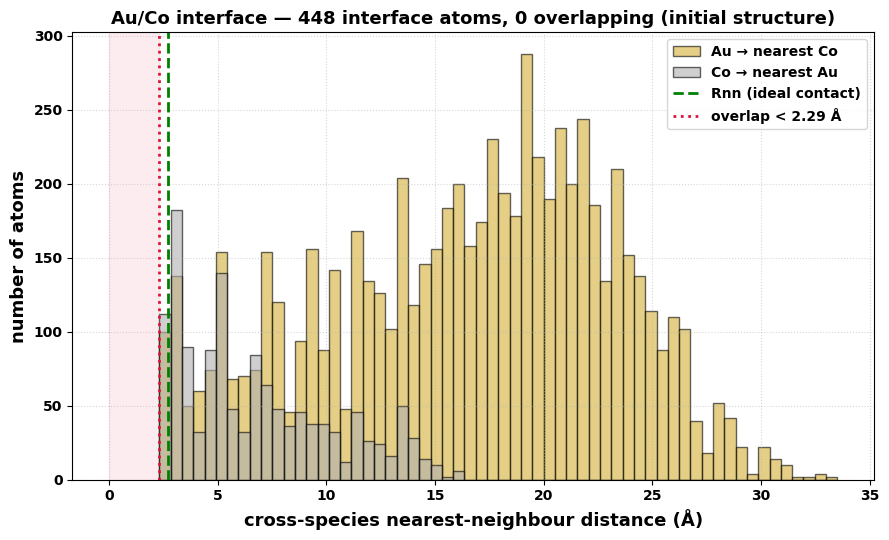

In [5]:
cubeA.interface_distance_histogram('Au', 'Co', Rnn=2.7, noOutput=False);

##### Geometry optimization

In [6]:
# ---------------------------------------------------------------------------
# 8. Geometry optimization of the dumbbell
# ---------------------------------------------------------------------------
pyNMBu.centertxt("geometry optimization", size=18, weight="bold", bgc="#880002")
cubeA.optimize(calculator="eam", eam_potential="./coords/cubeX/CuAgAuNiPdPtAlPbFeMoTaWMgCoTiZr_Zhou04.eam.alloy", noOutput=False,
               xyz_file="./coords/cubeX/dumbbell_CoWire_opt_tmp.xyz", fthreshold=0.15)
pyNMBu.write("coords/cubeX/dumbbell_CoWire_opt.xyz", cubeA.NP_opt)

 - Calculator                 : ase EAM calculator (CuAgAuNiPdPtAlPbFeMoTaWMgCoTiZr_Zhou04.eam.alloy)
 - Optimizer                  : ase Quasi Newton
 - Number of atoms            : 8298
 - XYZ frames will be saved to: ./coords/cubeX/dumbbell_CoWire_opt_tmp.xyz
 - Initial potential energy   : -30448.4 eV
 - Energy per atom            : -3.67 eV/atom
 - Max residual force         : 2.26 eV/Å  (threshold 0.15)



                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 13:14:57   -30448.386732       2.2621



KeyboardInterrupt


KeyboardInterrupt



#### Post-processing: local order descriptors

In [ ]:
db = pyNMB.from_file("coords/cubeX/dumbbell_CoWire.xyz", skipSymmetryAnalyzis=True, noOutput=True)
cnp = db.common_neighbour_parameter(Xnn=2.95*1.3, noOutput=False)
db.plot_local_order(descriptor='cnp')
db.local_order_populations(descriptor="cnp", decimals=2, noOutput=False);
pyNMBu.write("coords/cubeX/dumbbell_CoWire_cnp.script", db.jMol_cnp)

### Comparison of the (q4,q6) maps

In [ ]:
for o, rnn in [(ico, 2.884), (db, 2.884)]:
    o.steinhardt_q(Xnn=rnn*1.3, l=4)
    o.steinhardt_q(Xnn=rnn*1.3, l=6)
pyNMBu.compare_q4q6_map([ico, db], labels=['ico', 'db'], ncols=2, nrows=1)

In [25]:
pyNMB.end()

**End at:** Friday 12 June 2026, 10:03:18  
**Duration:** 00:21:15 522ms

# End